# Jobsheet 3 - Teknik Regrresi Gambar

## Praktikum D1 – Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

### setup dan generator dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

# generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
  r = np.random.randint(min_r, max_r + 1)     # radius acak
  img = np.zeros((img_size, img_size), dtype=np.uint8)
  cx = np.random.randint(r, img_size - r)      # center x
  cy = np.random.randint(r, img_size - r)      # center y
  cv2.circle(img, (cx, cy), r, (255,), -1)    # lingkaran penuh terisi
  img = (img / 255.0).astype(np.float32)
  # 3 channel biar kompatibel CNN
  img3 = np.stack([img, img, img], axis=-1)
  return img3, float(r), (cx, cy)

### tebak apa - tampilkan contoh gambar tanpa label

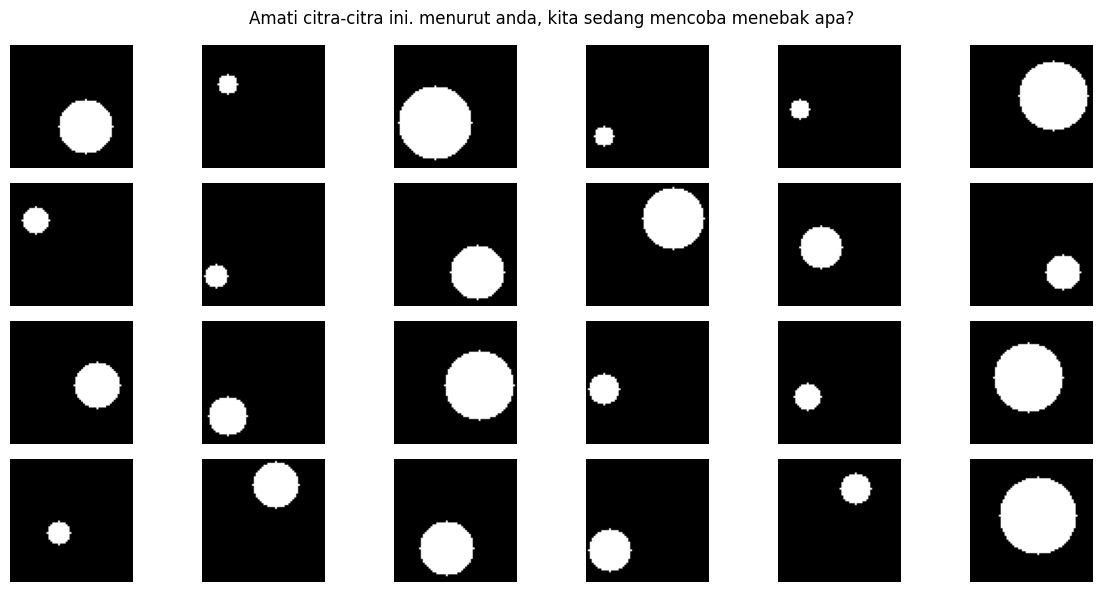

In [ ]:
# buat 24 contoh visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]

# grid tanpa label
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.axis('off')

plt.suptitle("Amati citra-citra ini. menurut anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

### Buka Jawaban — Target yang Ingin Diprediksi

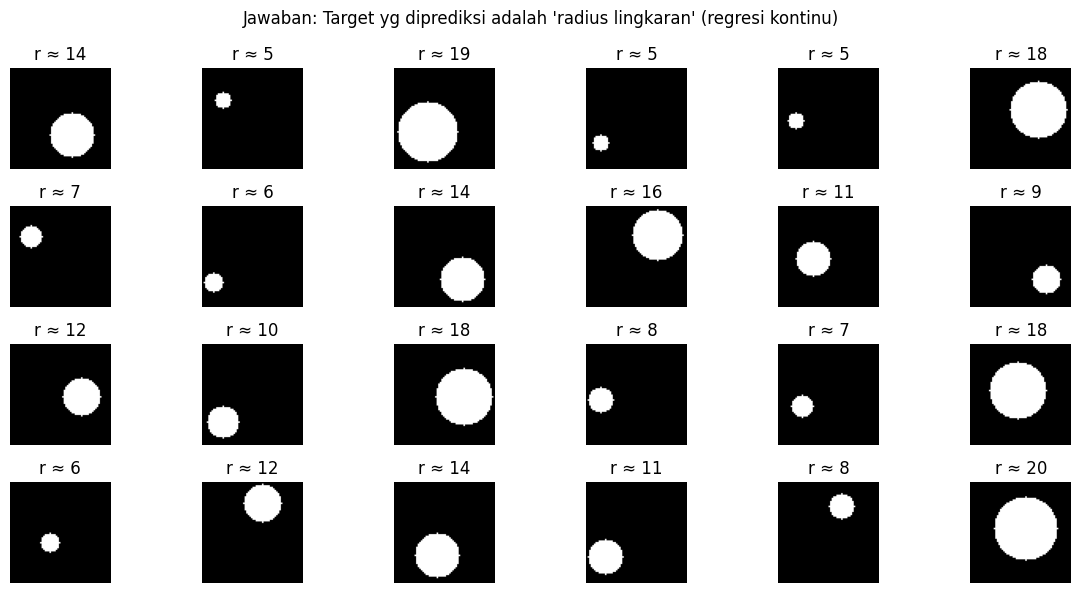

In [ ]:
# tampilkan kembali, sekarang tampilkan radius (label) dijudul tiap subplot
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.title(f"r ≈ {int(rads[i])}")
  plt.axis('off')

plt.suptitle("Jawaban: Target yg diprediksi adalah 'radius lingkaran' (regresi kontinu)")
plt.tight_layout()
plt.show()

###  (Opsional) Latih CNN Kecil untuk Memprediksi Radius

In [ ]:
N = 30
X, y, C = zip(*[make_sample() for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# model cnn sederhana
model = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)       # output regresi
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=12, batch_size=64, verbose=0)

# eval
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred) ** 2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
MAE=0.922 | RMSE=1.113 | R²=0.615


### Plot history & True vs Predicted:

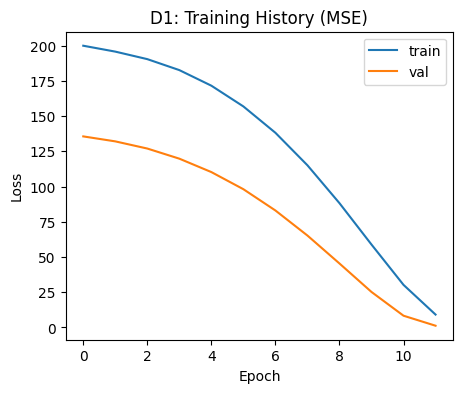

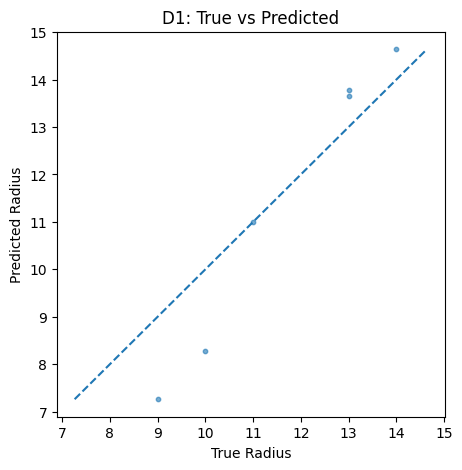

In [ ]:
# plot loss
plt.figure(figsize=(5, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# scatter true vs pred
plt.figure(figsize=(5, 5))
plt.scatter(yte, y_pred, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, '--')
plt.title("D1: True vs Predicted")
plt.xlabel("True Radius")
plt.ylabel("Predicted Radius")
plt.show()

### Tantangan Mini

*   Ubah rentang radius (mis. 8–28) dan lihat dampaknya ke MAE/RMSE/R².
*   Tambahkan noise (blur, noise Gaussian) ke citra → bagaimana performanya?
*   Jadikan tugas multi-output: prediksikan [r,cx,cy][r, c_x, c_y][r,cx,cy] sekaligus; metrik evaluasi apa yang cocok?

In [ ]:
# panggil generator dengan rentang radius baru
def make_dataset(n_samples=1000, img_size=64, min_r=8, max_r=28):
    X, y = [], []
    for _ in range(n_samples):
        img3, r, _ = make_sample(img_size=img_size, min_r=min_r, max_r=max_r)
        X.append(img3)
        y.append(r)
    return np.array(X), np.array(y)

X, y = make_dataset(1000, min_r=8, max_r=28)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# modif code generator dengan augmentasi noise
def make_sample_noisy(img_size=64, min_r=5, max_r=20, noise_type='gaussian', sigma=0.15):
  img3, r, center = make_sample(img_size, min_r, max_r)

  if noise_type == 'gaussian':
    # add gaussian noise
    noise = np.random.normal(0, sigma, img3.shape)
    img3 = np.clip(img3 + noise, 0.0, 1.0).astype(np.float32)
  elif noise_type == 'blur':
    # tambahakan gaussian blue
    img_gray = (img3[:, :, 0] * 255).astype(np.uint8)
    blurred = cv2.GaussianBlur(img_gray, (7,7), 2.0) / 255.0
    img3 = np.stack([blurred, blurred, blurred], axis=-1).astype(np.float32)

  return img3, r, center

# Tugas Multi-Output $[r, c_x, c_y]$ & Metrik Evaluasi
# dataset multi output
def make_dataset_multi(n_samples=1000, img_size=64):
  X, Y = [], []
  for _ in range(n_samples):
    img3, r, (cx, cy) = make_sample(img_size)
    X.append(img3)
    Y.append([r, cx, cy])
  return np.array(X), np.array(Y)

X, Y = make_dataset_multi(1000)
X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2, random_state=42)

# arsitektur multi output
model_multi = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='linear') # Output 3 neuron: [r, cx, cy]
])

model_multi.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model_multi.fit(X_tr, Y_tr, epochs=15, validation_data=(X_te, Y_te), batch_size=32)

# eval terpisah per target
Y_pred = model_multi.predict(X_te)

# metrics spesifik
mae_r = mean_absolute_error(Y_te[:, 0], Y_pred[:, 0])
mae_cx = mean_absolute_error(Y_te[:, 1], Y_pred[:, 1])
mae_cy = mean_absolute_error(Y_te[:, 2], Y_pred[:, 2])

# center euclidean distance error (pengukur presisi posisi tengah)
center_error = np.sqrt((Y_te[:, 1] - Y_pred[:, 1])**2 + (Y_te[:, 2] - Y_pred[:, 2])**2)
mean_center_error = np.mean(center_error)

print(f"MAE Radius (r)  : {mae_r:.3f} px")
print(f"MAE Center X    : {mae_cx:.3f} px")
print(f"MAE Center Y    : {mae_cy:.3f} px")
print(f"Mean Center Distance Error: {mean_center_error:.3f} px")

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 215ms/step - loss: 271.2332 - mae: 11.9577 - val_loss: 55.9681 - val_mae: 5.8347
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - loss: 31.5620 - mae: 3.9673 - val_loss: 15.2103 - val_mae: 2.9602
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - loss: 12.7181 - mae: 2.5077 - val_loss: 7.1322 - val_mae: 1.8115
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - loss: 7.5703 - mae: 1.8126 - val_loss: 5.1677 - val_mae: 1.4756
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - loss: 5.3966 - mae: 1.5178 - val_loss: 3.9187 - val_mae: 1.3488
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 4.0890 - mae: 1.3008 - val_loss: 3.0583 - val_mae: 1.1302
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - loss: 3.3770 - mae: 1.1611 - val_loss: 2.5734 - val_mae: 1.0079
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - loss: 2.7646 - mae: 1.0648 - val_loss: 2.4193 - val_mae: 1.0063
Epoch 9/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/st

Evaluasi tugas regresi multi-output [r, cx ,cy ] memerlukan pemisahan metrik antara dimensi skala (r) dan lokasi spasial (cx, cy). Berdasarkan hasil pengujian, metrik MAE per-variabel dan Mean Center Distance Error merupakan metrik paling representatif karena berbasis satuan piksel (px) yang intuitif. Model CNN berhasil mencapai presisi tinggi dalam mengekstraksi radius (MAE r =0,444 px), sementara lokalisasi posisi pusat menghasilkan penyimpangan sumbu MAE cx =0,843 px dan MAE cy =0,910 px. Secara keseluruhan, kalkulasi jarak Euklides menunjukkan rata-rata pergeseran spasial titik pusat (E
center) sebesar 1,374 px, yang mengonfirmasi bahwa arsitektur CNN mampu mempelajari fitur geometri dan koordinat spasial lingkaran secara konvergen dan akurat.

## Praktikum D2 – Menebak Umur Manusia dari Foto Wajah (UTKFace)

### Langkah 1 — Membuat Akun Kaggle dan Mengunduh kaggle.json
Agar dapat mengakses dataset publik Kaggle, mahasiswa perlu membuat akun terlebih dahulu.
Ikuti langkah berikut:
1. Buka situs https://www.kaggle.com
2. Daftar menggunakan email Google atau GitHub.
3. Setelah login, klik profil di kanan atas → pilih “Account”.
4. Gulir ke bawah ke bagian API → klik “Create New API Token”.
5. File bernama kaggle.json akan otomatis terunduh ke komputer Anda. File ini berisi API key pribadi agar Colab bisa mengakses dataset Kaggle Anda

Simpan file kaggle.json dengan baik (jangan dibagikan ke orang lain).

### Langkah 2 — Mengunggah kaggle.json ke Colab

In [1]:
from google.colab import files
files.upload() # pilih file kaggle.json dari komputer Anda

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "delafajarmulia",\r\n  "key": "KGAT_49d6651d7b7325f31d22f7dee48e8671"\r\n}'}

In [2]:
import os
import shutil
from pathlib import Path

kaggle_src = Path("kaggle.json")
kaggle_dir = Path.home() / ".kaggle"
kaggle_dest = kaggle_dir / "kaggle.json"

if kaggle_src.exists():
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(kaggle_src, kaggle_dest)
    os.chmod(kaggle_dest, 0o600)

    !pip -q install kaggle
    print("✅ Kaggle API siap digunakan.")
else:
    print("❌ kaggle.json belum ditemukan. Upload file tersebut terlebih dahulu.")

✅ Kaggle API siap digunakan.


### Langkah 3 — Mengunduh Dataset UTKFace dari Kaggle

In [6]:
!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -q /content/utkface-new.zip -d /content/utk

print("✅ Dataset UTKFace berhasil diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
replace /content/utk/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ✅ Dataset UTKFace berhasil diekstrak.


### Langkah 4 — Menampilkan Contoh Gambar Dataset

In [8]:
import os, glob
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Ambil seluruh file .jpg di dalam folder /content/utk/
files = sorted(glob.glob("/content/utk/**/*.jpg", recursive=True))
print(f"Total gambar ditemukan: {len(files)}")

# 2. Parse label umur dari nama file
def parse_age_from_name(fp):
    return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files], dtype=np.float32)

# 3. Split dataset 80% train dan 20% test
train_files, test_files, y_train, y_test = train_test_split(
    files, ages, test_size=0.2, random_state=42
)

IMG_SIZE = 160

# 4. Fungsi loader gambar
def load_img(fp, label):
    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0, label

# 5. Buat tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_files, y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files, y_test)).map(load_img).batch(64)

print("✅ Dataset siap dilatih.")

Total gambar ditemukan: 66976
✅ Dataset siap dilatih.


### Langkah 5 — Siapkan Dataset untuk Model

In [9]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Cek ketersediaan hardware (GPU/CPU)
hardware = "GPU" if tf.config.list_physical_devices('GPU') else "CPU"
print(f"Hardware: {hardware}")

# 2. Inisialisasi base model MobileNetV2 (Freeze Backbone)
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base_model.trainable = False  # Tahap awal: freeze bobot backbone

# 3. Konstruksi arsitektur head regresi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1)(x)  # Output tunggal untuk prediksi umur

model = tf.keras.Model(inputs, outputs)

# 4. Kompilasi model dengan optimizer Adam & loss MSE
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

# 5. Tampilkan ringkasan arsitektur model
model.summary()

Hardware: CPU
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Langkah 6 — Membangun Model dengan Transfer Learning

Epoch 1/10
838/838 ━━━━━━━━━━━━━━━━━━━━ 1514s 2s/step - loss: 182.9341 - mae: 10.0088 - val_loss: 138.8252 - val_mae: 8.6118 - learning_rate: 0.0010
Epoch 2/10
838/838 ━━━━━━━━━━━━━━━━━━━━ 1472s 2s/step - loss: 142.4364 - mae: 8.7384 - val_loss: 127.0867 - val_mae: 8.1754 - learning_rate: 0.0010
Epoch 3/10
838/838 ━━━━━━━━━━━━━━━━━━━━ 1460s 2s/step - loss: 134.8089 - mae: 8.4991 - val_loss: 121.4803 - val_mae: 8.0419 - learning_rate: 0.0010
Epoch 4/10
838/838 ━━━━━━━━━━━━━━━━━━━━ 1428s 2s/step - loss: 129.6779 - mae: 8.3342 - val_loss: 117.0843 - val_mae: 7.8548 - learning_rate: 0.0010
Epoch 5/10
838/838 ━━━━━━━━━━━━━━━━━━━━ 1502s 2s/step - loss: 124.8818 - mae: 8.1888 - val_loss: 112.7801 - val_mae: 7.7100 - learning_rate: 0.0010
Epoch 6/10
838/838 ━━━━━━━━━━━━━━━━━━━━ 1468s 2s/step - loss: 120.8402 - mae: 8.0581 - val_loss: 109.4691 - val_mae: 7.5746 - learning_rate: 0.0010
Epoch 7/10
838/838 ━━━━━━━━━━━━━━━━━━━━ 1440s 2s/step - loss: 115.8970 - mae: 7.9196 - val_loss: 106.6394 - val

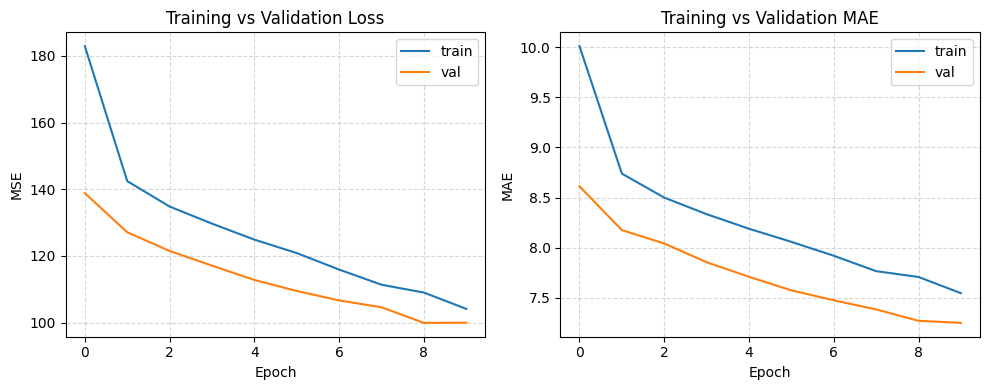

In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Callback untuk pelatihan yang lebih stabil
cb = [
    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=2,
        factor=0.5,
        min_lr=1e-5,  # Perbaikan typo: 1e-5 (sebelumnya 1e5)
        monitor='val_loss'
    )
]

# Proses pelatihan model (Tahap 1)
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
)

# Visualisasi perubahan loss dan MAE selama pelatihan
plt.figure(figsize=(10, 4))

# Plot 1: MSE Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Plot 2: MAE Metric
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Penjelasan singkat arsitektur:
* MobileNetV2 sudah “terlatih melihat dunia”, kita hanya menyesuaikan layer akhir untuk memetakan wajah → umur.
* GlobalAveragePooling2D mengubah fitur spasial menjadi vektor global.
* Dropout membantu mencegah overfitting.
* Output 1 neuron: prediksi umur dalam skala kontinu.

### Langkah 7 — Melatih Model (Tahap 1 – Frozen)

Epoch 1/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 1930s 2s/step - loss: 104.8982 - mae: 7.4220 - val_loss: 109.3397 - val_mae: 8.1634 - learning_rate: 1.0000e-04
Epoch 2/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 1935s 2s/step - loss: 42.3802 - mae: 4.8342 - val_loss: 50.7828 - val_mae: 5.4077 - learning_rate: 1.0000e-04
Epoch 3/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 1877s 2s/step - loss: 26.6930 - mae: 3.8511 - val_loss: 29.7104 - val_mae: 3.9038 - learning_rate: 1.0000e-04
Epoch 4/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 1884s 2s/step - loss: 19.8131 - mae: 3.3149 - val_loss: 32.4406 - val_mae: 4.0880 - learning_rate: 1.0000e-04
Epoch 5/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 1913s 2s/step - loss: 15.8313 - mae: 2.9612 - val_loss: 32.7230 - val_mae: 3.9936 - learning_rate: 1.0000e-04


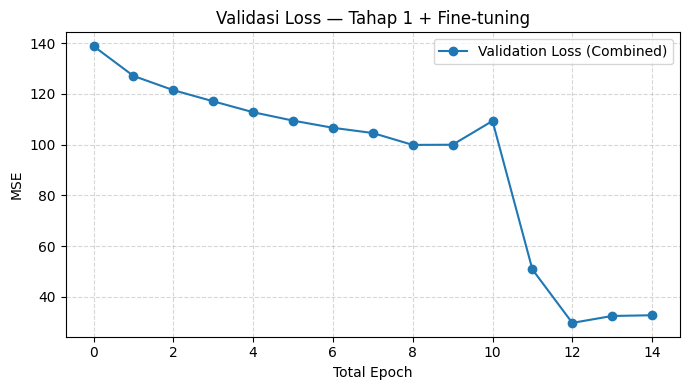

In [11]:
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Unfreeze base model, lalu bekukan semua layer kecuali 30 layer terakhir
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False  # Bekukan layer awal agar fitur umum tidak rusak

# 2. Recompile model dengan learning rate lebih kecil (1e-4)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

# 3. Proses pelatihan tahap fine-tuning (Tahap 2)
history_ft = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=cb,
    verbose=1
)

# 4. Visualisasi grafik loss gabungan (Tahap 1 + Fine-tuning)
plt.figure(figsize=(7, 4))
plt.plot(
    history.history['val_loss'] + history_ft.history['val_loss'],
    label='Validation Loss (Combined)',
    marker='o',
    color='tab:blue',
    linewidth=1.5
)
plt.title("Validasi Loss — Tahap 1 + Fine-tuning", fontsize=12)
plt.xlabel("Total Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Interpretasi:
* Jika val_loss menurun dan stabil, model mulai memahami hubungan antara fitur wajah dan umur.
* Jika val_loss naik terus, berarti model mulai overfitting — butuh dropout atau augmentasi tambahan.

### Langkah 9 — Evaluasi Akhir (MAE, RMSE, R²)

MAE  = 3.90 tahun
RMSE = 5.45 tahun
R²   = 0.935


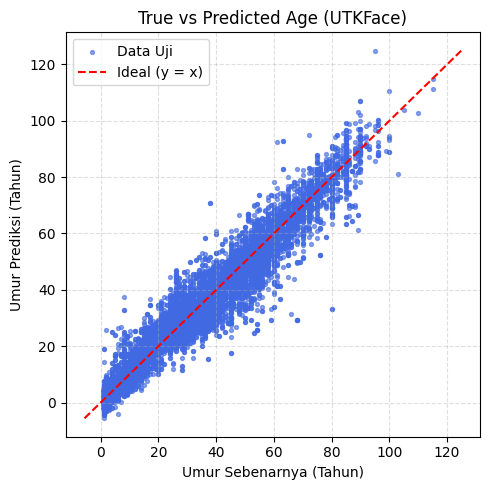

In [12]:
from math import sqrt
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prediksi seluruh data uji (batching)
y_pred = np.concatenate(
    [model.predict(batch[0], verbose=0).ravel() for batch in test_ds]
)

# 2. Perhitungan metrik evaluasi regresi
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(np.mean((y_test - y_pred) ** 2))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R²   = {r2:.3f}")

# 3. Plot "Umur Sebenarnya vs Umur Prediksi" (Scatter Plot)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6, color='royalblue', label='Data Uji')

# Garis diagonal ideal (y = x)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red', linewidth=1.5, label='Ideal (y = x)')

plt.xlabel("Umur Sebenarnya (Tahun)")
plt.ylabel("Umur Prediksi (Tahun)")
plt.title("True vs Predicted Age (UTKFace)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Interpretasi hasil:
* Semakin rapat titik ke garis merah → semakin akurat prediksi.
* Nilai R² mendekati 1 menunjukkan model menjelaskan variasi data dengan baik.
* MAE kecil → rata-rata selisih umur prediksi dengan kenyataan kecil (mis. ±3 tahun).

### Langkah 10 — Melihat Contoh Prediksi Nyata

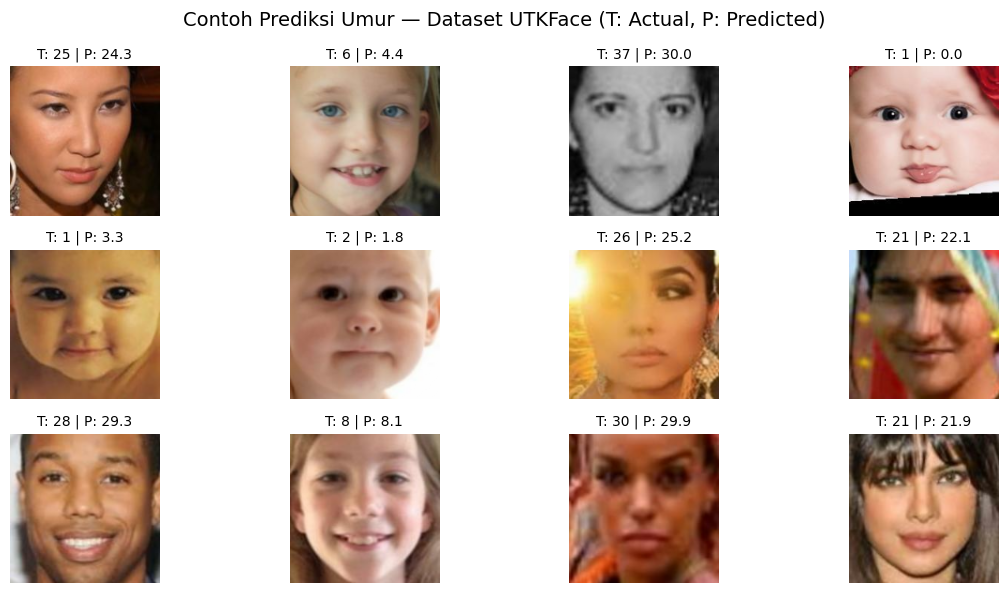

In [13]:
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Pilih 12 sampel acak dari data uji (test_files)
sample_paths = random.sample(test_files, 12)

plt.figure(figsize=(12, 6))

for i, path in enumerate(sample_paths):
    # 2. Preprocessing citra sampel
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    # 3. Ekstraksi umur asli & prediksi umur oleh model
    try:
        true_age = int(os.path.basename(path).split('_')[0])
    except (ValueError, IndexError):
        true_age = "?"

    pred_age = model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]

    # 4. Plot citra beserta label (T = True Age, P = Predicted Age)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img.numpy())
    plt.title(f"T: {true_age} | P: {pred_age:.1f}", fontsize=10)
    plt.axis('off')

plt.suptitle("Contoh Prediksi Umur — Dataset UTKFace (T: Actual, P: Predicted)", fontsize=14)
plt.tight_layout()
plt.show()

## Penugasan 1 - Gunakan foto pribadi untuk menampilkan ujicoba prediksi usia kalian

📸 Silakan upload foto pribadi kamu (format .jpg / .jpeg / .png):


Saving foto-dela.jpg to foto-dela.jpg


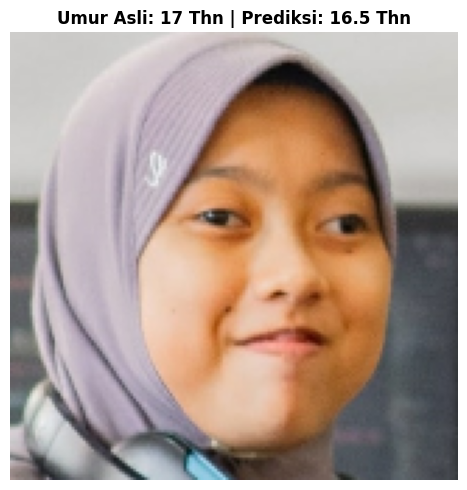

✅ Hasil Estimasi Usia Model: 16.5 tahun (Selisih: 0.5 tahun)


In [17]:
from google.colab import files
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Upload foto pribadi dari komputer
print("📸 Silakan upload foto pribadi kamu (format .jpg / .jpeg / .png):")
uploaded = files.upload()

# Ambil nama file foto yang baru di-upload
file_path = list(uploaded.keys())[0]

# 2. Preprocess foto agar sesuai format input model (160x160)
img_raw = tf.io.read_file(file_path)
img = tf.image.decode_image(img_raw, channels=3)
img_resized = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

# 3. Prediksi umur dengan model
img_batch = tf.expand_dims(img_resized, 0)  # Tambah dimensi batch [1, 160, 160, 3]
pred_age = model.predict(img_batch, verbose=0).ravel()[0]

# 4. Tentukan umur aslimu untuk perbandingan di laporan
UMUR_ASLI = 17

# 5. Visualisasi Hasil
plt.figure(figsize=(5, 5))
plt.imshow(img_resized.numpy())
plt.title(f"Umur Asli: {UMUR_ASLI} Thn | Prediksi: {pred_age:.1f} Thn", fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"✅ Hasil Estimasi Usia Model: {pred_age:.1f} tahun (Selisih: {abs(pred_age - UMUR_ASLI):.1f} tahun)")

Pengujian model regresi fine-tuned MobileNetV2 menggunakan sampel foto pribadi menunjukkan tingkat akurasi yang baik. Model memprediksi usia sebesar 16.5 tahun dari usia sebenarnya yaitu 17 tahun (dengan nilai selisih error sebesar 0.5 tahun). Hasil yang presisi ini mengindikasikan bahwa lapisan ekstraksi fitur konvolusi berhasil mengenali karakteristik spasial wajah (seperti proporsi rasio mata-hidung-mulut dan tekstur kulit) yang terdistribusi secara baik sebagaimana pola pada dataset UTKFace.